In [1]:
!pip install ultralytics
!pip install roboflow

  Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-fft 1.3.8 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
datase

In [2]:
!pip install "numpy<2.0"

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
datasets 4.4.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.7, but you have notebook 6.5.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
google-colab 

In [16]:
import torch
import torch.nn as nn 
import torchvision
import json
import copy
import os
import numpy as np
import tempfile
import sys 
import io 
import matplotlib.pyplot as plt
import random
import glob
import torchvision.transforms as T
import cv2

from PIL import Image
from ultralytics import YOLO
from PIL import Image
from roboflow import Roboflow
from torchvision import datasets, models, transforms
from torchvision.datasets import CocoDetection
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from tqdm import tqdm

In [4]:
rf = Roboflow(api_key="sNwZKFyXE0vHSdAqPXX0")
project = rf.workspace("main-workspace-vcien").project("birdnest-nzpjl-inn3e")
version = project.version(4)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...


In [5]:
def safe_to_tensor(pic):
    img_array = np.array(pic)
    tensor = torch.tensor(img_array, dtype=torch.float32)
    
    if tensor.ndim == 2:   # Grayscale
        tensor = tensor.unsqueeze(0)
    elif tensor.ndim == 3: # RGB
        tensor = tensor.permute(2, 0, 1)
        
    return tensor / 255.0

def get_transform(train):
    trans = []
    trans.append(transforms.Lambda(safe_to_tensor))
    stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    trans.append(transforms.Normalize(*stats))
    
    return transforms.Compose(trans)

train_dataset = CocoDetection(
    root="BirdNest-4/train",
    annFile="BirdNest-4/train/_annotations.coco.json",
    transform=get_transform(train=True) 
)

val_dataset = CocoDetection(
    root="BirdNest-4/valid",
    annFile="BirdNest-4/valid/_annotations.coco.json",
    transform=get_transform(train=False) 
)

test_dataset = CocoDetection(
    root="BirdNest-4/test",
    annFile="BirdNest-4/test/_annotations.coco.json",
    transform=get_transform(train=False)
)

def collate_fn(batch):
    images, targets = tuple(zip(*batch))
    images = list(images) 

    processed_targets = []
    
    for i, target in enumerate(targets):
        processed_target = {}
        
        boxes = []
        labels = []
        area = []
        iscrowd = []
        img_id = torch.tensor([i]) 

        for annotation in target:
            # 1. Geometry
            x, y, w, h = annotation['bbox']
            # Convert XYWH to XYXY (Standard for PyTorch Models)
            boxes.append([x, y, x + w, y + h])
            
            # 2. Labels
            labels.append(annotation['category_id'])
            
            # 3. Extras for COCO Eval
            area.append(annotation.get('area', w * h)) 
            iscrowd.append(annotation.get('iscrowd', 0))
            
            # 4. Image ID (Take from first annotation)
            if 'image_id' in annotation:
                img_id = torch.tensor([annotation['image_id']])

        # Convert to Tensors
        if boxes:
            processed_target['boxes'] = torch.as_tensor(boxes, dtype=torch.float32)
            processed_target['labels'] = torch.as_tensor(labels, dtype=torch.int64)
            processed_target['area'] = torch.as_tensor(area, dtype=torch.float32)
            processed_target['iscrowd'] = torch.as_tensor(iscrowd, dtype=torch.int64)
        else:
            # Handle Background Images (No Boxes)
            processed_target['boxes'] = torch.zeros((0, 4), dtype=torch.float32)
            processed_target['labels'] = torch.zeros((0,), dtype=torch.int64)
            processed_target['area'] = torch.zeros((0,), dtype=torch.float32)
            processed_target['iscrowd'] = torch.zeros((0,), dtype=torch.int64)
        
        processed_target['image_id'] = img_id
        processed_targets.append(processed_target)

    return images, processed_targets

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn, num_workers=2)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [6]:
class NetworkTrainer:
    def __init__(self, model, optimizer, lr_scheduler, device):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.device = device
        self.best_map = 0.0
        self.best_model_state = copy.deepcopy(self.model.state_dict())

    def compute_loss(self, loader):
        self.model.train()
        total_loss = 0.0
        count = 0

        with torch.no_grad():
            for imgs, targets in loader:
                imgs = [img.to(self.device) for img in imgs]
                targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]

                loss_dict = self.model(imgs, targets)
                loss = sum(loss for loss in loss_dict.values())

                total_loss += loss.item()
                count += 1

        return total_loss / count if count > 0 else 0.0

    def compute_map(self, loader, iou_type="bbox"):
        self.model.eval()
        results = []
    
        with torch.no_grad():
            for imgs, targets in loader:
                imgs = [img.to(self.device) for img in imgs]
                outputs = self.model(imgs)
    
                for output, target in zip(outputs, targets):
                    image_id = int(target["image_id"].item())
                    if "boxes" in output:
                        boxes = output["boxes"].cpu().numpy()
                        scores = output["scores"].cpu().numpy()
                        labels = output["labels"].cpu().numpy()
    
                        for box, score, label in zip(boxes, scores, labels):
                            x1, y1, x2, y2 = box
                            w, h = x2 - x1, y2 - y1
                            results.append({
                                "image_id": image_id,
                                "category_id": int(label),
                                "bbox": [float(x1), float(y1), float(w), float(h)],
                                "score": float(score)
                            })
    
        # Save results as temp JSON
        with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
            json.dump(results, f)
            result_file = f.name
    
        base_dataset = loader.dataset
        if isinstance(base_dataset, torch.utils.data.Subset):
            base_dataset = base_dataset.dataset  
    
        coco_gt = base_dataset.coco
    
        # Suppress COCO printing (loadRes + eval + summarize)
        old_stdout = sys.stdout
        sys.stdout = io.StringIO()
    
        coco_dt = coco_gt.loadRes(result_file)
        coco_eval = COCOeval(coco_gt, coco_dt, iouType=iou_type)
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
        sys.stdout = old_stdout 
    
        return coco_eval.stats[0]
    
    def fit(self, train_loader, val_loader, num_epochs=30):
        for epoch in range(num_epochs):
            self.model.train()
            total_loss = 0.0

            pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

            for imgs, targets in pbar:
                imgs = [img.to(self.device) for img in imgs]
                targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]

                # Forward
                loss_dict = self.model(imgs, targets)
                losses = sum(loss for loss in loss_dict.values())

                # Backward
                self.optimizer.zero_grad()
                losses.backward()
                self.optimizer.step()

                total_loss += losses.item()
                current_avg_loss = total_loss / (pbar.n + 1)
                # pbar.set_postfix({"Loss": f"{current_avg_loss:.4f}", "Batch Loss": f"{losses.item():.4f}"})

            self.lr_scheduler.step()

            # Compute train/val losses + val mAP
            train_loss = self.compute_loss(train_loader)
            val_loss = self.compute_loss(val_loader)
            val_map = self.compute_map(val_loader)

            print(f"Epoch {epoch+1}/{num_epochs} "
                  f"- Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mAP@50-95: {val_map:.4f}")

            # Save best model based on mAP
            if val_map > self.best_map:
                self.best_map = val_map
                self.best_model_state = copy.deepcopy(self.model.state_dict())
                torch.save(self.model.state_dict(), "best_faster_efficient.pth")
                print(f"✅ Best model saved at epoch {epoch+1} with mAP {self.best_map:.4f}")

        # Load best model at the end
        self.model.load_state_dict(self.best_model_state)

In [7]:
class BackboneWrapper(nn.Module):
    def __init__(self, backbone, out_channels):
        super().__init__()
        self.backbone = backbone
        self.out_channels = out_channels
        
    def forward(self, x):
        feat = self.backbone(x)
        # Faster R-CNN expects a Dict[name, tensor]
        return {"0": feat}

def get_efficientnet_fasterrcnn(num_classes):
    # 1. Load Backbone
    backbone_raw = efficientnet_b5(weights=EfficientNet_B5_Weights.DEFAULT).features
    
    # 2. Wrap it (Fixes the "Tensor vs Dict" crash)
    backbone = BackboneWrapper(backbone_raw, out_channels=2048)

    # 3. Generate Anchors
    # FIX: "sizes" has length 1 (one tuple), so "aspect_ratios" must also have length 1.
    # We use one feature map, so we define one set of anchors for it.
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),), 
        aspect_ratios=((0.5, 1.0, 2.0),) 
    )

    # 4. ROI Pooler
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'], 
        output_size=7,
        sampling_ratio=2
    )

    # 5. Build Model
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )

    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        # --- ADD THESE LINES ---
        min_size=640,   # Resize shortest edge to 640
        max_size=1024   # Ensure longest edge doesn't exceed 1024
    )
    return model

In [8]:
from torch.utils.data import Subset

small_train_dataset = Subset(train_dataset, list(range(20)))
small_val_dataset = Subset(val_dataset, list(range(10)))

small_train_loader = DataLoader(small_train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
small_val_loader = DataLoader(small_val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4  # Grade A, B, C + Background

model = get_efficientnet_fasterrcnn(num_classes=NUM_CLASSES)
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

trainer = NetworkTrainer(model, optimizer, lr_scheduler, device)
trainer.fit(train_loader, val_loader, num_epochs=30)

Epoch 1/30: 100%|██████████| 632/632 [13:55<00:00,  1.32s/it]


Epoch 1/30 - Train Loss: 0.1351 | Val Loss: 0.1670 | Val mAP@50-95: 0.3731
✅ Best model saved at epoch 1 with mAP 0.3731


Epoch 2/30: 100%|██████████| 632/632 [13:56<00:00,  1.32s/it]


Epoch 2/30 - Train Loss: 0.1084 | Val Loss: 0.1434 | Val mAP@50-95: 0.4648
✅ Best model saved at epoch 2 with mAP 0.4648


Epoch 3/30: 100%|██████████| 632/632 [13:58<00:00,  1.33s/it]


...

Epoch 15/30 - Train Loss: 0.0650 | Val Loss: 0.1059 | Val mAP@50-95: 0.6334


Epoch 16/30: 100%|██████████| 632/632 [13:59<00:00,  1.33s/it]


Epoch 16/30 - Train Loss: 0.0644 | Val Loss: 0.1070 | Val mAP@50-95: 0.6296


Epoch 17/30:  44%|████▍     | 279/632 [06:12<07:51,  1.34s/it]


KeyboardInterrupt: 

In [11]:
# reload the trained model with correct num_classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_efficientnet_fasterrcnn(num_classes=4)
model.load_state_dict(torch.load("best_faster_efficient.pth", map_location=device))
model.to(device)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(640,), max_size=1024, mode='bilinear')
  )
  (backbone): BackboneWrapper(
    (backbone): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(48, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
              (1): BatchNorm2d(48, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2

In [ ]:
# reload the trained model with correct num_classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = fasterrcnn_resnet50_fpn(num_classes=4)
model.load_state_dict(torch.load("/kaggle/input/resnet50-model/pytorch/default/1/resnet50-fasterrcnn-13.pth", map_location=device))
model.to(device)
model.eval()

In [12]:
def compute_iou(gt_boxes, dt_boxes):
    """
    Compute IoU between all GT and detection boxes (vectorized).
    Boxes are in [x, y, w, h] format.
    Returns a (len(gt_boxes), len(dt_boxes)) matrix.
    """
    if len(gt_boxes) == 0 or len(dt_boxes) == 0:
        return np.zeros((len(gt_boxes), len(dt_boxes)))

    gt = gt_boxes.copy()
    dt = dt_boxes.copy()

    gt[:, 2:] += gt[:, :2]  # Convert [x,y,w,h] -> [x1,y1,x2,y2]
    dt[:, 2:] += dt[:, :2]

    gt_area = (gt[:, 2] - gt[:, 0]) * (gt[:, 3] - gt[:, 1])
    dt_area = (dt[:, 2] - dt[:, 0]) * (dt[:, 3] - dt[:, 1])

    inter_x1 = np.maximum(gt[:, None, 0], dt[None, :, 0])
    inter_y1 = np.maximum(gt[:, None, 1], dt[None, :, 1])
    inter_x2 = np.minimum(gt[:, None, 2], dt[None, :, 2])
    inter_y2 = np.minimum(gt[:, None, 3], dt[None, :, 3])

    inter_w = np.maximum(0, inter_x2 - inter_x1)
    inter_h = np.maximum(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    union_area = gt_area[:, None] + dt_area[None, :] - inter_area
    iou = inter_area / (union_area + 1e-7)
    return iou


# --- (Combined, Efficient Evaluation Function) ---
def evaluate_model(model, data_loader, device, iou_threshold=0.5, score_threshold=0.5):
    """
    Runs model evaluation once and calculates BOTH mAP and fixed-threshold P/R.
    """
    model.eval()

    # --- Get COCO ground truth API ---
    base_dataset = data_loader.dataset
    if isinstance(base_dataset, torch.utils.data.Subset):
        base_dataset = base_dataset.dataset
    coco_gt = base_dataset.coco

    # --- 1. Variables for mAP ---
    coco_results = []
    
    # --- 2. Variables for manual P/R ---
    tp, fp, fn = 0, 0, 0

    with torch.no_grad():
        pbar = tqdm(data_loader, desc="Evaluating", leave=True)
        for imgs, targets in pbar:
            imgs = [img.to(device) for img in imgs]
            
            # --- RUN MODEL ONLY ONCE ---
            outputs = model(imgs)

            for output, target in zip(outputs, targets):
                image_id = int(target["image_id"].item())
                
                # Get raw model outputs
                boxes_raw = output["boxes"].cpu().numpy()    # [x1, y1, x2, y2]
                scores_raw = output["scores"].cpu().numpy()
                labels_raw = output["labels"].cpu().numpy()

                # ------------------------------------
                # PART A: Format results for mAP (COCOeval)
                # ------------------------------------
                for box, score, label in zip(boxes_raw, scores_raw, labels_raw):
                    x1, y1, x2, y2 = map(float, box)
                    coco_results.append({
                        "image_id": image_id,
                        "category_id": int(label),
                        "bbox": [x1, y1, float(x2 - x1), float(y2 - y1)], # [x, y, w, h]
                        "score": float(score)
                    })

                # ------------------------------------
                # PART B: Calculate fixed-threshold P/R
                # ------------------------------------
                
                # Get ground truth
                gt_ann_ids = coco_gt.getAnnIds(imgIds=image_id)
                gt_anns = coco_gt.loadAnns(gt_ann_ids)
                gt_boxes = np.array([ann['bbox'] for ann in gt_anns], dtype=np.float32) # [x, y, w, h]
                gt_labels = np.array([ann['category_id'] for ann in gt_anns], dtype=np.int64)

                # Filter detections by score
                keep = scores_raw >= score_threshold
                dt_boxes = boxes_raw[keep]  # [x1, y1, x2, y2]
                dt_scores = scores_raw[keep]
                dt_labels = labels_raw[keep]

                # Convert dt_boxes to [x, y, w, h] for compute_iou
                dt_boxes_coco = np.stack(
                    [dt_boxes[:, 0], dt_boxes[:, 1], dt_boxes[:, 2] - dt_boxes[:, 0], dt_boxes[:, 3] - dt_boxes[:, 1]],
                    axis=1
                )

                # --- Matching Logic (with bug fix) ---
                if len(gt_boxes) == 0:
                    fp += len(dt_boxes)
                    continue
                if len(dt_boxes) == 0:
                    fn += len(gt_boxes)
                    continue

                iou_matrix = compute_iou(gt_boxes, dt_boxes_coco)
                matched_gt = set()
                dt_order = np.argsort(dt_scores)[::-1]

                for dt_idx in dt_order:
                    best_gt_idx = -1
                    best_iou = iou_threshold  # Start with min IoU

                    for gt_idx in range(len(gt_boxes)):
                        if gt_idx in matched_gt:
                            continue
                        if gt_labels[gt_idx] != dt_labels[dt_idx]:
                            continue
                        
                        iou = iou_matrix[gt_idx, dt_idx]
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = gt_idx
                    
                    if best_gt_idx != -1:
                        tp += 1
                        matched_gt.add(best_gt_idx)
                    else:
                        fp += 1
                
                fn += len(gt_boxes) - len(matched_gt)

    # --- END OF LOOP ---
    
    all_metrics = {}

    # ------------------------------------
    # PART 1: Finalize mAP Calculation
    # ------------------------------------
    print("\n--- COCO mAP Results ---")
    if not coco_results:
        print("No detections found, skipping mAP calculation.")
    else:
        with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
            json.dump(coco_results, f)
            result_file = f.name
        
        # Suppress pycocotools print statements
        old_stdout = sys.stdout
        sys.stdout = io.StringIO()
        
        coco_dt = coco_gt.loadRes(result_file)
        coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
        coco_eval.evaluate()
        coco_eval.accumulate()
        
        sys.stdout = old_stdout # Restore stdout
        
        # NOW print the summary and save all stats
        coco_eval.summarize()
        
        all_metrics.update({
            "mAP@50-95": float(coco_eval.stats[0]),
            "mAP@50": float(coco_eval.stats[1]),
            "mAP@75": float(coco_eval.stats[2]),
            "mAP_small": float(coco_eval.stats[3]),
            "mAP_medium": float(coco_eval.stats[4]),
            "mAP_large": float(coco_eval.stats[5]),
            "AR@1": float(coco_eval.stats[6]),
            "AR@10": float(coco_eval.stats[7]),
            "AR@100": float(coco_eval.stats[8]),
            "AR_small": float(coco_eval.stats[9]),
            "AR_medium": float(coco_eval.stats[10]),
            "AR_large": float(coco_eval.stats[11]),
        })

    # ------------------------------------
    # PART 2: Finalize P/R Calculation
    # ------------------------------------
    print(f"\n--- Metrics @ IoU={iou_threshold}, Score={score_threshold} ---")
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    f1 = 2 * precision * recall / (precision + recall + 1e-7)
    
    print(f"TP: {tp}, FP: {fp}, FN: {fn}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    
    all_metrics.update({
        "Precision": float(precision),
        "Recall": float(recall),
        "F1": float(f1),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn)
    })

    return all_metrics

In [13]:
# Call the single evaluation function
all_results = evaluate_model(
    model, 
    test_loader, 
    device, 
    iou_threshold=0.5, 
    score_threshold=0.5
)

print("\n--- Summary ---")
print(f"mAP@50-95: {all_results.get('mAP@50-95', 0):.4f}")
print(f"mAP@50:    {all_results.get('mAP@50', 0):.4f}")
print(f"Precision:   {all_results.get('Precision', 0):.4f}")
print(f"Recall:    {all_results.get('Recall', 0):.4f}")

Evaluating: 100%|██████████| 61/61 [00:12<00:00,  4.83it/s]


--- COCO mAP Results ---
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.605
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.782
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.761
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.605
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.792
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.792
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.792
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.792

--- Metri

In [19]:
# --- CONFIGURATION ---
MODEL_WEIGHTS_PATH = "/kaggle/working/best_faster_efficient.pth"
DATASET_ROOT = "BirdNest-4"

# Images are directly inside 'test'
TEST_IMG_DIR = os.path.join(DATASET_ROOT, "test")
# COCO JSON is inside 'test'
TEST_JSON_PATH = os.path.join(DATASET_ROOT, "test", "_annotations.coco.json")

NUM_IMAGES = 64
CONF_THRESHOLD = 0.25
NUM_CLASSES = 4 

# Visualization Config
GT_COLOR = (0, 255, 0)    # Green
PRED_COLOR = (0, 0, 255)  # Blue
TEXT_SCALE = 0.6
TEXT_THICKNESS = 1
BOX_THICKNESS = 2

CLASS_NAMES = {
    0: "background", 
    1: "Grade A",
    2: "Grade B",
    3: "Grade C"
}

In [20]:
# --- MODEL INITIALIZATION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Loading EfficientNet-B5 Faster R-CNN model on {device}...")

# Initialize the custom structure
model = get_efficientnet_fasterrcnn(num_classes=NUM_CLASSES)

if os.path.exists(MODEL_WEIGHTS_PATH):
    print(f"Loading weights from {MODEL_WEIGHTS_PATH}...")
    try:
        model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))
        print("Weights loaded successfully.")
    except Exception as e:
        print(f"ERROR loading weights: {e}")
else:
    print(f"WARNING: Weights not found at {MODEL_WEIGHTS_PATH}. Using random initialization.")

model.to(device)
model.eval()

# --- 2. HELPER: LOAD COCO JSON (UNCHANGED) ---
def load_coco_ground_truths(json_path):
    if not os.path.exists(json_path):
        print(f"Error: Annotation file not found at {json_path}")
        return {}

    print(f"Loading annotations from {json_path}...")
    with open(json_path, 'r') as f:
        data = json.load(f)

    img_id_to_name = {img['id']: img['file_name'] for img in data['images']}
    gt_dict = {}
    for ann in data['annotations']:
        img_id = ann['image_id']
        filename = img_id_to_name.get(img_id)
        
        if not filename: continue
        if filename not in gt_dict:
            gt_dict[filename] = []
            
        x, y, w, h = ann['bbox']
        cat_id = ann['category_id'] 
        
        x1, y1, x2, y2 = int(x), int(y), int(x + w), int(y + h)
        gt_dict[filename].append([x1, y1, x2, y2, cat_id])
        
    return gt_dict

# --- 3. DRAWING FUNCTION (UNCHANGED) ---
def draw_boxes(image, gts, preds, class_names):
    vis_image = image.copy()
    
    # Draw GT (Green, Bottom-Right)
    for box in gts:
        x1, y1, x2, y2, cls_id = box
        label = f"GT: {class_names.get(cls_id, str(cls_id))}"
        cv2.rectangle(vis_image, (x1, y1), (x2, y2), GT_COLOR, BOX_THICKNESS)
        (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, TEXT_SCALE, TEXT_THICKNESS)
        cv2.rectangle(vis_image, (x2 - w, y2 - h - 5), (x2, y2), GT_COLOR, -1)
        cv2.putText(vis_image, label, (x2 - w + 2, y2 - 5), cv2.FONT_HERSHEY_SIMPLEX, TEXT_SCALE, (0, 0, 0), TEXT_THICKNESS, cv2.LINE_AA)

    # Draw Preds (Blue, Top-Left)
    if preds:
        p_boxes = preds['boxes'].cpu().numpy()
        p_labels = preds['labels'].cpu().numpy()
        p_scores = preds['scores'].cpu().numpy()
        
        for box, label_id, score in zip(p_boxes, p_labels, p_scores):
            if score < CONF_THRESHOLD: continue
            x1, y1, x2, y2 = box.astype(int)
            label = f"Pred: {class_names.get(label_id, str(label_id))} ({score:.2f})"
            cv2.rectangle(vis_image, (x1, y1), (x2, y2), PRED_COLOR, BOX_THICKNESS)
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, TEXT_SCALE, TEXT_THICKNESS)
            cv2.rectangle(vis_image, (x1, y1), (x1 + w, y1 + h + 5), PRED_COLOR, -1)
            cv2.putText(vis_image, label, (x1 + 2, y1 + h + 2), cv2.FONT_HERSHEY_SIMPLEX, TEXT_SCALE, (255, 255, 255), TEXT_THICKNESS, cv2.LINE_AA)
            
    return vis_image

Loading EfficientNet-B5 Faster R-CNN model on cuda...
Loading weights from /kaggle/working/best_faster_efficient.pth...
Weights loaded successfully.


Loading annotations from BirdNest-4/test/_annotations.coco.json...
Finding test images in BirdNest-4/test...
Found 122 images. Sampling 64...
Running predictions...
Displaying plot...


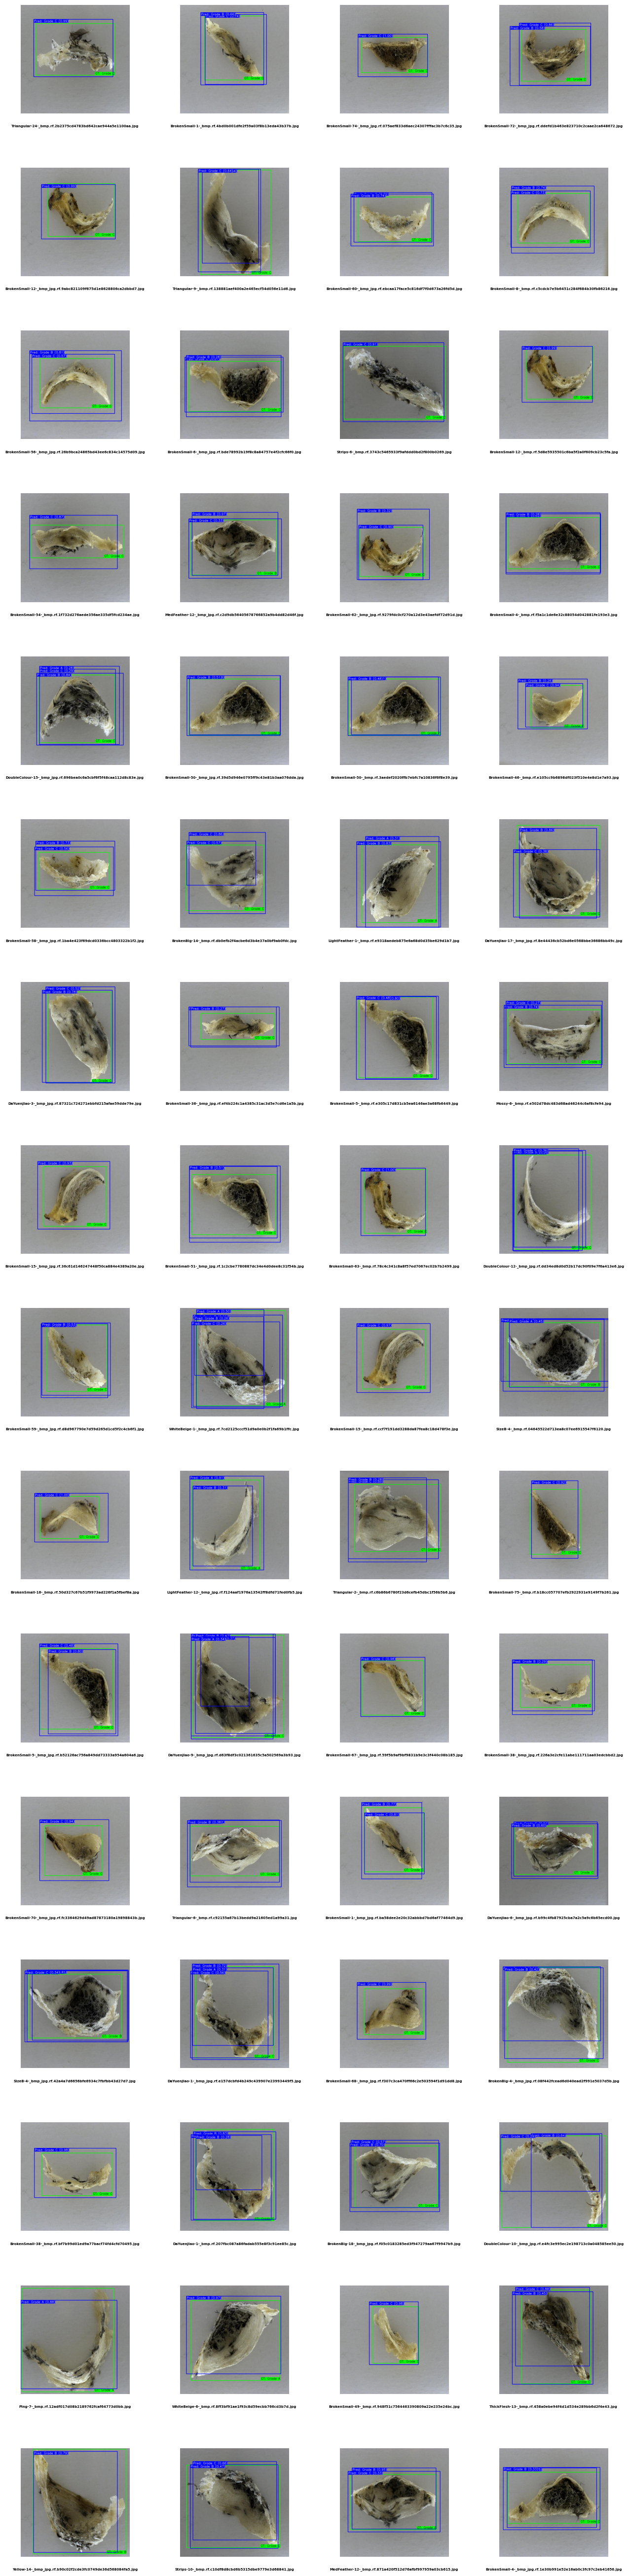

In [21]:
# A. Load GT Dictionary
coco_gts = load_coco_ground_truths(TEST_JSON_PATH)

# B. Find Images
print(f"Finding test images in {TEST_IMG_DIR}...")
image_patterns = [os.path.join(TEST_IMG_DIR, ext) for ext in ("*.jpg", "*.jpeg", "*.png")]
all_image_paths = []
for pattern in image_patterns:
    all_image_paths.extend(glob.glob(pattern))

if not all_image_paths:
    print(f"Error: No images found in {TEST_IMG_DIR}.")
else:
    num_to_sample = min(NUM_IMAGES, len(all_image_paths))
    print(f"Found {len(all_image_paths)} images. Sampling {num_to_sample}...")
    sampled_image_paths = random.sample(all_image_paths, num_to_sample)

    # Grid setup
    num_cols = 4
    num_rows = int(np.ceil(num_to_sample / num_cols))
    
    fig_w = num_cols * 4
    fig_h = num_rows * 4.2 
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_w, fig_h))
    axes = axes.flatten()

    print("Running predictions...")

    for i, img_path in enumerate(sampled_image_paths):
        ax = axes[i]
        
        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        file_name = os.path.basename(img_path)
        gts = coco_gts.get(file_name, [])

        # Run Model
        img_tensor = T.ToTensor()(img_rgb).to(device)
        with torch.no_grad():
            preds = model([img_tensor])[0]

        vis_image = draw_boxes(img_rgb, gts, preds, CLASS_NAMES)
        
        ax.imshow(vis_image)
        ax.axis('off')
        
        # Tiny text + Offset
        ax.text(0.5, -0.1, file_name, 
                transform=ax.transAxes, 
                ha='center', va='top', 
                fontsize=5, color='black', weight='bold')

    # Turn off unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # More breathing room between rows
    plt.subplots_adjust(hspace=0.5)
    
    print("Displaying plot...")
    plt.show()
    fig.savefig("fasterrcnn_effnetb5_grid_named.png")